# Notebook 10 — Rainfall dataset selection: automatic vs conventional gauges

**Why this notebook.** The MGB water balance is forced with rainfall, and we will bias-correct a
gridded product (CHIRPS) against **IDEAM rain-gauge observations**. But IDEAM offers *two* gauge
networks, and they are **not** the same thing. Before touching the model we settle, with evidence,
**which network to trust** — because that choice propagates into every discharge and sediment result.

The two candidates:

| | **Automatic** (telemetry) | **Conventional** (manual) |
|---|---|---|
| Source | datos.gov.co `s54a-sgyg` (10-min, API) | DHIME portal (daily) |
| Sensor | electronic tipping-bucket | observer reads a rain gauge at 07:00 |
| Record | recent (~2010→) | long (we pulled **2008–2018**) |
| Validation | raw, "no validado" by IDEAM | quality-controlled (mostly *Definitivo*) |
| Our holdings | ~94 basin stations | **294 basin stations** |

This is a **preliminary study**: four head-to-head tests (coverage, agreement, ENSO signal, record
quality), then a verdict. The winner becomes the gauge truth for the CHIRPS correction (next notebook).

In [1]:
import glob, pathlib
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
%matplotlib inline
REPO=None
for b in [pathlib.Path.cwd()]+list(pathlib.Path.cwd().parents):
    if (b/'data'/'processed'/'minibacias.tif').exists(): REPO=b; break
proc=REPO/'data'/'processed'; raw=REPO/'data'/'raw'/'observed'/'precip'

# conventional (DHIME) — the merged, QC'd basin dataset (notebook build_precip_gauges.py)
cv  = pd.read_csv(proc/'precip_gauges_inventory.csv', dtype={'code':str})
cvd = pd.read_csv(proc/'precip_gauges_daily.csv', dtype={'code':str}).dropna(subset=['precip_mm'])
cvd['date']=pd.to_datetime(cvd['date'])
# automatic (Socrata)
au  = pd.read_csv(raw/'precip_auto_stations.csv', dtype={'code':str})
au['lat']=pd.to_numeric(au.lat,errors='coerce'); au['lon']=pd.to_numeric(au.lon,errors='coerce'); au=au.dropna(subset=['lat','lon'])
aud = pd.read_csv(raw/'precip_auto_daily_long.csv', dtype={'code':str}); aud=aud[aud.valid==1]; aud['date']=pd.to_datetime(aud['date'])
with rasterio.open(proc/'minibacias.tif') as s:
    sub=s.read(1); tr=s.transform; b=s.bounds; ext=[b.left,b.right,b.bottom,b.top]
print(f'CONVENTIONAL: {cv.code.nunique()} stations, {len(cvd):,} station-days')
print(f'AUTOMATIC   : {au.code.nunique()} stations, {len(aud):,} station-days')

CONVENTIONAL: 294 stations, 686,752 station-days
AUTOMATIC   : 94 stations, 70,367 station-days


## Test 1 — Spatial coverage

A bias-correction can only fix rainfall *where it has a gauge to anchor to*. So the first question is
simply: **how much of the basin does each network see?** We sample the basin and, at each point, measure
the distance to the nearest gauge of each network. The map shows the stations; the table quantifies the
gap — overall and for the **Cauca side** (west of −75.3°), the half the study cares about most for sediment.

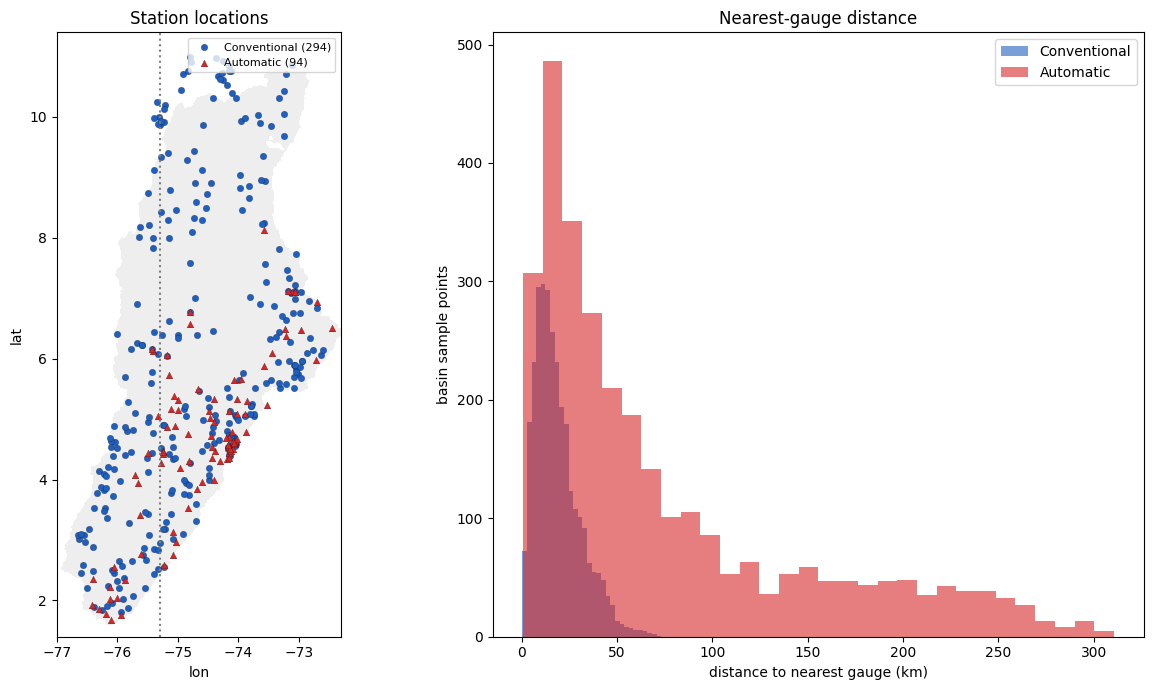

nearest-gauge distance (km)      automatic   conventional
  whole basin  median                46          16
  %% of basin >30 km from a gauge     63%%         17%%
  Cauca side   median                43          14
  Cauca side   %% >30 km              64%%         12%%


In [2]:
def km(a,o,c,d): return np.sqrt(((a-c)*111)**2+((o-d)*111*np.cos(np.radians((a+c)/2)))**2)
ys,xs=np.where(sub>0); s=np.random.RandomState(0).choice(len(ys),3000,replace=False)
plon=tr.c+(xs[s]+0.5)*tr.a; plat=tr.f+(ys[s]+0.5)*tr.e
def nearest(g): return np.min(km(plat[:,None],plon[:,None],g.lat.values[None,:],g.lon.values[None,:]),axis=1)
d_au=nearest(au); d_cv=nearest(cv); west=plon<-75.3

fig,ax=plt.subplots(1,2,figsize=(13,7))
ax[0].imshow(np.where(sub>0,1,np.nan),extent=ext,cmap='Greys',vmin=0,vmax=3,alpha=.3)
ax[0].scatter(cv.lon,cv.lat,c='#1f5fbf',s=22,label=f'Conventional ({cv.code.nunique()})',edgecolor='k',lw=.15)
ax[0].scatter(au.lon,au.lat,c='#d62728',marker='^',s=24,label=f'Automatic ({au.code.nunique()})',edgecolor='k',lw=.15)
ax[0].axvline(-75.3,ls=':',c='gray'); ax[0].set_title('Station locations'); ax[0].legend(loc='upper right',fontsize=8)
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat'); ax[0].set_xlim(ext[0],ext[1]); ax[0].set_ylim(ext[2],ext[3])
ax[1].hist(d_cv,bins=30,alpha=.6,color='#1f5fbf',label='Conventional'); ax[1].hist(d_au,bins=30,alpha=.6,color='#d62728',label='Automatic')
ax[1].set_xlabel('distance to nearest gauge (km)'); ax[1].set_ylabel('basin sample points'); ax[1].set_title('Nearest-gauge distance'); ax[1].legend()
plt.tight_layout(); plt.show()
print('nearest-gauge distance (km)      automatic   conventional')
print(f'  whole basin  median            {np.median(d_au):6.0f}      {np.median(d_cv):6.0f}')
print(f'  %% of basin >30 km from a gauge {100*np.mean(d_au>30):6.0f}%%     {100*np.mean(d_cv>30):6.0f}%%')
print(f'  Cauca side   median            {np.median(d_au[west]):6.0f}      {np.median(d_cv[west]):6.0f}')
print(f'  Cauca side   %% >30 km          {100*np.mean(d_au[west]>30):6.0f}%%     {100*np.mean(d_cv[west]>30):6.0f}%%')

## Test 2 — Do they agree where they overlap?

Where an automatic and a conventional gauge sit close together (<12 km) we can compare them directly. If
they matched, the choice would be cosmetic. They do **not**: we compare daily correlation and the ratio of
annual totals over 2015–16. A ratio < 1 means the automatic tipping-bucket **under-catches** (missed
tips during intense rain + dropped 10-min intervals) relative to the observer-read conventional gauge.

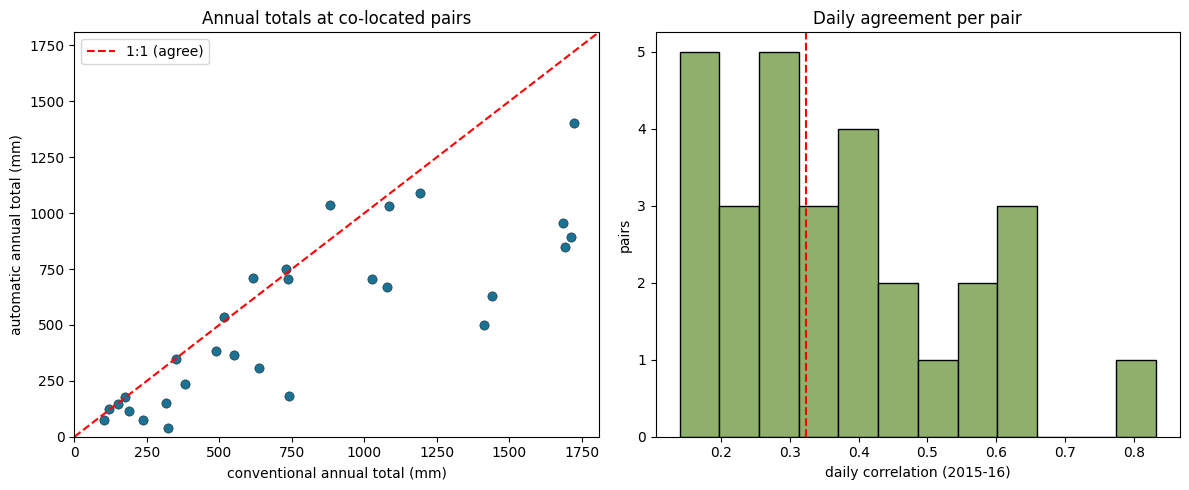

co-located pairs (<12 km): 29
  median daily correlation : 0.32   (1 = identical day-to-day)
  automatic/conventional annual-total ratio (median): 0.69   -> automatic under-catches ~31%%


In [3]:
xa=[];xd=[];cors=[]
for _,a in au.iterrows():
    dist=km(a.lat,a.lon,cv.lat,cv.lon); j=dist.idxmin()
    if dist.loc[j]<12:
        A=aud[aud.code==a.code]; D=cvd[cvd.code==cv.loc[j,'code']]
        m=A.merge(D,on='date'); m=m[(m.date.dt.year>=2015)&(m.date.dt.year<=2016)]
        if len(m)>60:
            xa.append(m.p_mm.sum()/2); xd.append(m.precip_mm.sum()/2); cors.append(m.p_mm.corr(m.precip_mm))
xa=np.array(xa); xd=np.array(xd)
fig,ax=plt.subplots(1,2,figsize=(12,5))
mx=max(xa.max(),xd.max())*1.05
ax[0].scatter(xd,xa,s=45,c='#1C7293',edgecolor='k',lw=.3); ax[0].plot([0,mx],[0,mx],'r--',label='1:1 (agree)')
ax[0].set_xlabel('conventional annual total (mm)'); ax[0].set_ylabel('automatic annual total (mm)')
ax[0].set_title('Annual totals at co-located pairs'); ax[0].legend(); ax[0].set_xlim(0,mx); ax[0].set_ylim(0,mx)
ax[1].hist(cors,bins=12,color='#8FB06B',edgecolor='k'); ax[1].axvline(np.median(cors),c='r',ls='--')
ax[1].set_xlabel('daily correlation (2015-16)'); ax[1].set_ylabel('pairs'); ax[1].set_title('Daily agreement per pair')
plt.tight_layout(); plt.show()
print(f'co-located pairs (<12 km): {len(xa)}')
print(f'  median daily correlation : {np.median(cors):.2f}   (1 = identical day-to-day)')
print(f'  automatic/conventional annual-total ratio (median): {np.median(xa/xd):.2f}   -> automatic under-catches ~{100*(1-np.median(xa/xd)):.0f}%%')

## Test 3 — Does each reproduce the ENSO signal?

The study rests on **2011 (La Niña, wet)** being clearly wetter than **2015–16 (El Niño, dry)**. A usable
network must reproduce that *known* contrast. For each network we take stations with data in both periods
and compare their mean daily rainfall. Both should land above the 1:1 line; the question is whether each
has *enough* stations to show it robustly.

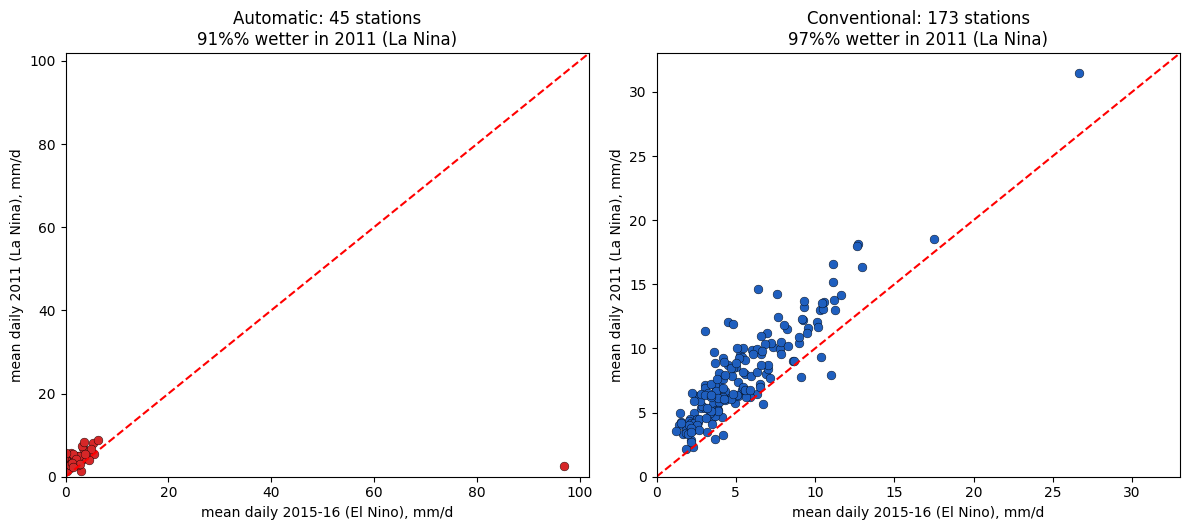

ENSO ratio 2011/(2015-16): automatic 1.85x (45 st) | conventional 1.53x (173 st)


In [4]:
def enso(daily,val):
    m11=daily[daily.date.dt.year==2011].groupby('code')[val].agg(m='mean',n='size')
    m56=daily[daily.date.dt.year.isin([2015,2016])].groupby('code')[val].agg(m='mean',n='size')
    p=m11.join(m56,lsuffix='11',rsuffix='56',how='inner'); p=p[(p.n11>=150)&(p.n56>=300)]
    return p
pa=enso(aud,'p_mm'); pc=enso(cvd,'precip_mm')
fig,ax=plt.subplots(1,2,figsize=(12,5.4))
for a,(p,ttl,col) in zip(ax,[(pa,'Automatic',' #d62728'),(pc,'Conventional','#1f5fbf')]):
    mx=max(p.m11.max(),p.m56.max())*1.05
    a.scatter(p.m56,p.m11,s=40,c=col.strip(),edgecolor='k',lw=.3); a.plot([0,mx],[0,mx],'r--')
    wet=100*(p.m11>p.m56).mean()
    a.set_title(f'{ttl}: {len(p)} stations\n{wet:.0f}%% wetter in 2011 (La Nina)')
    a.set_xlabel('mean daily 2015-16 (El Nino), mm/d'); a.set_ylabel('mean daily 2011 (La Nina), mm/d')
    a.set_xlim(0,mx); a.set_ylim(0,mx)
plt.tight_layout(); plt.show()
print(f'ENSO ratio 2011/(2015-16): automatic {pa.m11.median()/pa.m56.median():.2f}x ({len(pa)} st) | conventional {pc.m11.median()/pc.m56.median():.2f}x ({len(pc)} st)')

## Test 4 — Record length & validation status

Calibration runs 2008–2018 (validate out-of-sample on 2011 & 2015–16), so **record length matters**, and
so does whether the data is quality-controlled. Conventional carries an IDEAM approval flag; automatic is
raw. The bars show usable stations per study year and the conventional approval mix.

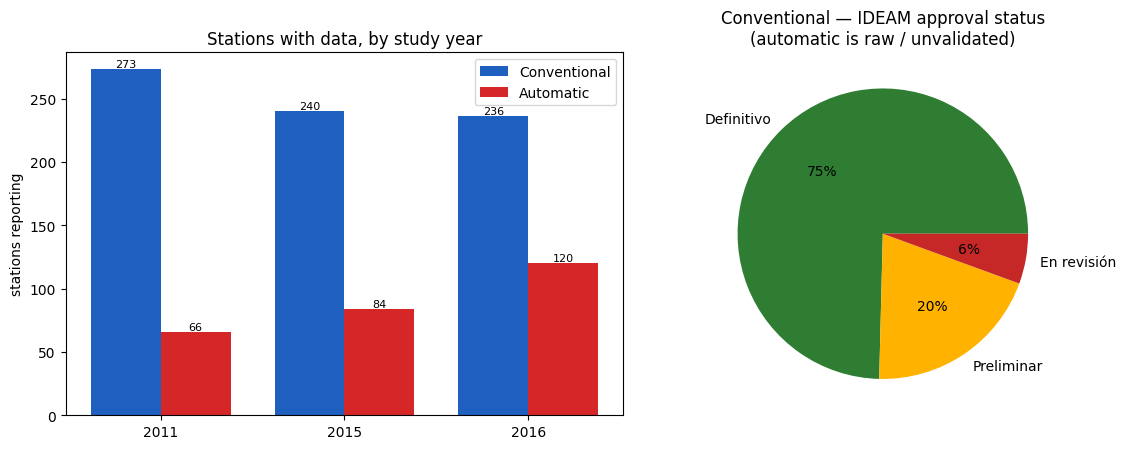

In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
yrs=[2011,2015,2016]
cvc=[ (cvd.date.dt.year==y).groupby(cvd.code).any().sum() if False else cvd[cvd.date.dt.year==y].code.nunique() for y in yrs]
auc=[ aud[aud.date.dt.year==y].code.nunique() for y in yrs]
x=np.arange(3); w=.38
ax[0].bar(x-w/2,cvc,w,color='#1f5fbf',label='Conventional'); ax[0].bar(x+w/2,auc,w,color='#d62728',label='Automatic')
ax[0].set_xticks(x); ax[0].set_xticklabels(yrs); ax[0].set_ylabel('stations reporting'); ax[0].set_title('Stations with data, by study year'); ax[0].legend()
for i,(a,c) in enumerate(zip(auc,cvc)):
    ax[0].text(i-w/2,c,str(c),ha='center',va='bottom',fontsize=8); ax[0].text(i+w/2,a,str(a),ha='center',va='bottom',fontsize=8)
appr=cvd['approval'].value_counts()
ax[1].pie(appr.values,labels=appr.index,autopct='%1.0f%%',colors=['#2E7D32','#FFB300','#C62828'])
ax[1].set_title('Conventional — IDEAM approval status\n(automatic is raw / unvalidated)')
plt.tight_layout(); plt.show()

## Test 5 — CHIRPS vs the conventional gauges: point-to-pixel skill

Tests 1–4 settled *which gauge network* to trust (conventional). This section asks the separate
question that decides the forcing for notebook 11: **can a gridded satellite–gauge product (CHIRPS
v2.0, 0.05°, daily) replace or complement the gauges?**

The gauges are the reference here, but that framing has a limit worth stating up front: a gauge is
truth *at a point*, while a CHIRPS cell is an area average over ~5 km. Some disagreement is therefore
expected and is not error — it is a scale mismatch. What we are looking for is *systematic* behaviour:
bias, wet-day inflation, and damping of extremes.

Compared over the three study years (2011 La Niña, 2015–16 El Niño), nearest-pixel to each gauge.

C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


CHIRPS years [2011, 2015, 2016] | gauges paired: 223 | paired station-days: 178,439
  daily correlation r   median 0.14   (IQR 0.10-0.19)
  annual-total bias     median -13.6 %   (47 % of gauges within +/-20 %)
  daily RMSE            median 13.7 mm/day


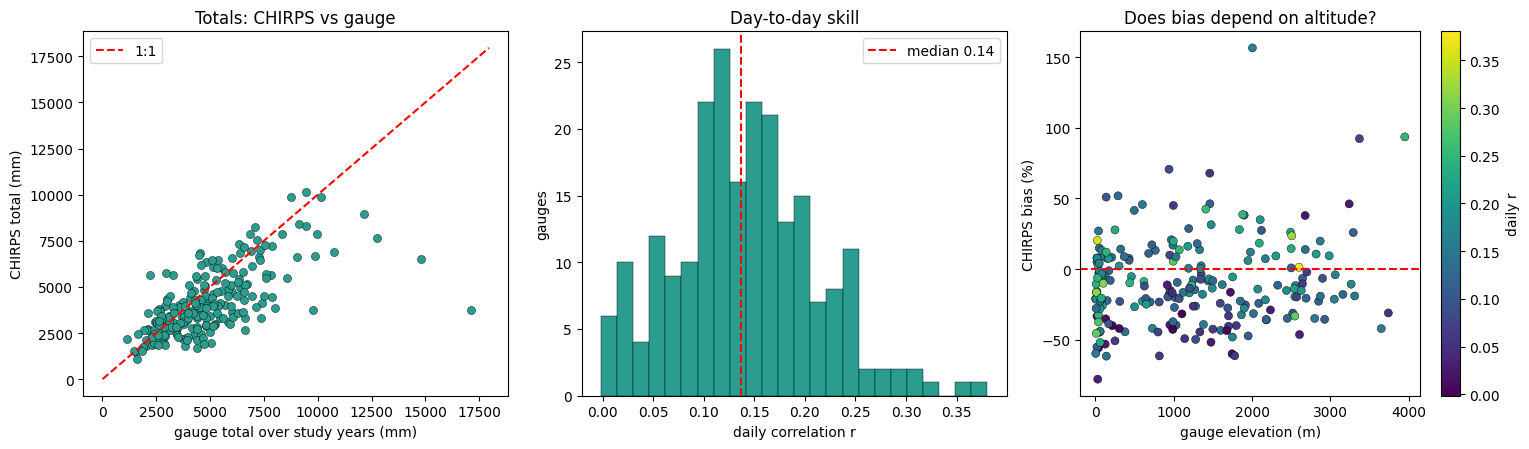

  lowland (<=1500 m, n=139): bias -11.6 %, r 0.14
  highland (>1500 m, n=77): bias -15.2 %, r 0.14


In [6]:
import xarray as xr

clim = REPO/'data'/'raw'/'climate'
files = sorted(clim.glob('chirps_basin_*.nc'))
assert files, 'run: python src/download_chirps.py'
ch = xr.concat([xr.open_dataset(f) for f in files], dim='time').sortby('time')
pr = ch['precip'].where(ch['precip'] >= 0)          # -9999 = missing

# nearest CHIRPS pixel under every gauge
sta = cv.dropna(subset=['lat','lon']).reset_index(drop=True)
px  = pr.sel(latitude=xr.DataArray(sta.lat.values, dims='st'),
             longitude=xr.DataArray(sta.lon.values, dims='st'), method='nearest').load()
chd = pd.DataFrame(px.values, index=pd.to_datetime(px.time.values), columns=sta.code.values)
chl = (chd.stack().rename('chirps_mm').rename_axis(['date','code']).reset_index())

yrs  = sorted({int(f.stem.split('_')[-1]) for f in files})
gg   = cvd[cvd.date.dt.year.isin(yrs)][['code','date','precip_mm']]
pair = gg.merge(chl, on=['code','date'], how='inner').dropna()

def _mets(d):
    tg, tc = d.precip_mm.sum(), d.chirps_mm.sum()
    return pd.Series({
        'n': len(d), 'r': d.precip_mm.corr(d.chirps_mm),
        'gauge_mm': tg, 'chirps_mm': tc,
        'bias_pct': 100*(tc/tg-1) if tg > 0 else np.nan,
        'rmse': np.sqrt(((d.chirps_mm-d.precip_mm)**2).mean()),
        'wet_g': 100*(d.precip_mm > 1).mean(), 'wet_c': 100*(d.chirps_mm > 1).mean(),
        'p95_g': d.precip_mm.quantile(.95), 'p95_c': d.chirps_mm.quantile(.95),
        'p99_g': d.precip_mm.quantile(.99), 'p99_c': d.chirps_mm.quantile(.99),
        'max_g': d.precip_mm.max(),         'max_c': d.chirps_mm.max()})

M = pair.groupby('code').apply(_mets, include_groups=False)
M = M[M.n >= 300].join(sta.set_index('code')[['alt','lat','lon','zona']])

print(f'CHIRPS years {yrs} | gauges paired: {len(M)} | paired station-days: {len(pair):,}')
print(f'  daily correlation r   median {M.r.median():.2f}   (IQR {M.r.quantile(.25):.2f}-{M.r.quantile(.75):.2f})')
print(f'  annual-total bias     median {M.bias_pct.median():+.1f} %   '
      f'({(M.bias_pct.abs() < 20).mean()*100:.0f} % of gauges within +/-20 %)')
print(f'  daily RMSE            median {M.rmse.median():.1f} mm/day')

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.6))
mx = max(M.gauge_mm.max(), M.chirps_mm.max())*1.05
ax[0].scatter(M.gauge_mm, M.chirps_mm, s=34, c='#2a9d8f', edgecolor='k', lw=.3)
ax[0].plot([0, mx], [0, mx], 'r--', label='1:1')
ax[0].set_xlabel('gauge total over study years (mm)'); ax[0].set_ylabel('CHIRPS total (mm)')
ax[0].set_title('Totals: CHIRPS vs gauge'); ax[0].legend()
ax[1].hist(M.r.dropna(), bins=24, color='#2a9d8f', edgecolor='k', lw=.3)
ax[1].axvline(M.r.median(), color='r', ls='--', label=f'median {M.r.median():.2f}')
ax[1].set_xlabel('daily correlation r'); ax[1].set_ylabel('gauges'); ax[1].set_title('Day-to-day skill'); ax[1].legend()
sc = ax[2].scatter(M.alt, M.bias_pct, s=34, c=M.r, cmap='viridis', edgecolor='k', lw=.3)
ax[2].axhline(0, color='r', ls='--'); plt.colorbar(sc, ax=ax[2], label='daily r')
ax[2].set_xlabel('gauge elevation (m)'); ax[2].set_ylabel('CHIRPS bias (%)')
ax[2].set_title('Does bias depend on altitude?')
plt.tight_layout(); plt.show()

hi = M[M.alt > 1500]; lo = M[M.alt <= 1500]
print(f'  lowland (<=1500 m, n={len(lo)}): bias {lo.bias_pct.median():+.1f} %, r {lo.r.median():.2f}')
print(f'  highland (>1500 m, n={len(hi)}): bias {hi.bias_pct.median():+.1f} %, r {hi.r.median():.2f}')

## Test 6 — Extremes and drizzle: the part that decides the *sediment* answer

This is the decisive test for this project, and it is why "which product has the better annual total"
is the wrong question. MUSLE erosion scales with rainfall **erosivity**, which is driven by the big
storms — not by the mean. Two failure modes matter:

- **Drizzle inflation** — a gridded product raining a little on too many days. It can match the annual
  total while spreading it across too many small events, which under-predicts erosion.
- **Extreme damping** — area-averaging a 5 km cell smooths the peak of a convective storm, so the
  95th/99th daily percentiles come out too low. This directly suppresses simulated sediment.

If CHIRPS shows either, it cannot be used raw as the erosion forcing, regardless of how good its
totals look.

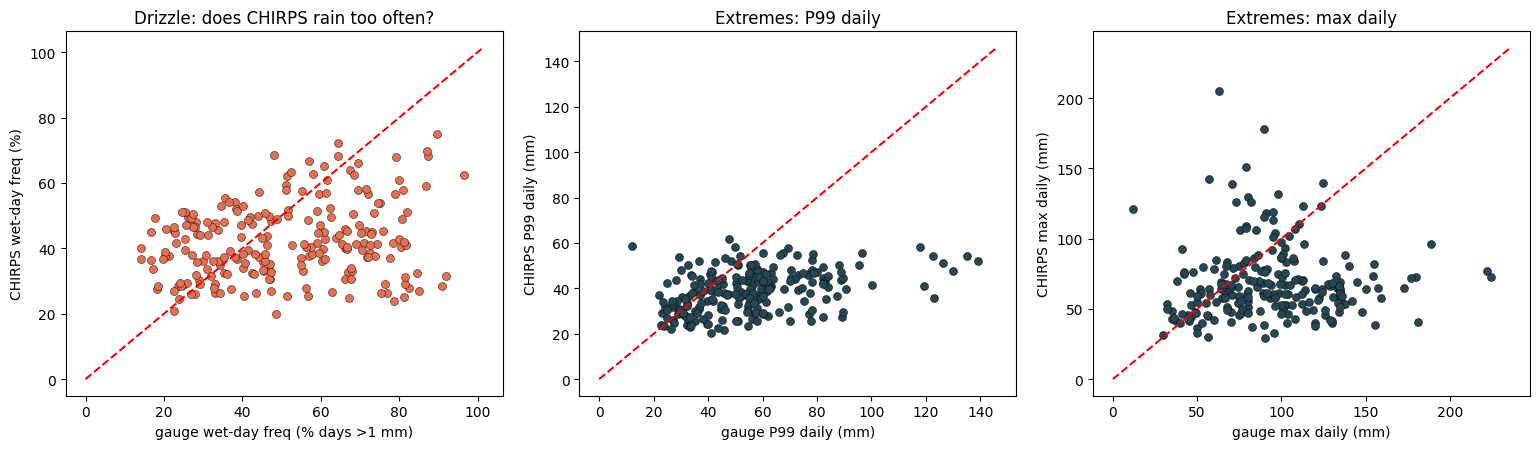

wet-day frequency : gauge 48.0 %  vs CHIRPS 41.0 %   (-6.2 pts)
P99 daily ratio   : CHIRPS/gauge 0.74   (damped)
max daily ratio   : CHIRPS/gauge 0.76
gauges where CHIRPS under-states P99: 78 %


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.6))
mxw = max(M.wet_g.max(), M.wet_c.max())*1.05
ax[0].scatter(M.wet_g, M.wet_c, s=34, c='#e76f51', edgecolor='k', lw=.3)
ax[0].plot([0, mxw], [0, mxw], 'r--')
ax[0].set_xlabel('gauge wet-day freq (% days >1 mm)'); ax[0].set_ylabel('CHIRPS wet-day freq (%)')
ax[0].set_title('Drizzle: does CHIRPS rain too often?')
for a, (g, c, lab) in zip(ax[1:], [(M.p99_g, M.p99_c, 'P99 daily'), (M.max_g, M.max_c, 'max daily')]):
    mm = max(g.max(), c.max())*1.05
    a.scatter(g, c, s=34, c='#264653', edgecolor='k', lw=.3); a.plot([0, mm], [0, mm], 'r--')
    a.set_xlabel(f'gauge {lab} (mm)'); a.set_ylabel(f'CHIRPS {lab} (mm)')
    a.set_title(f'Extremes: {lab}')
plt.tight_layout(); plt.show()

dw   = (M.wet_c - M.wet_g).median()
r99  = (M.p99_c / M.p99_g).median()
rmax = (M.max_c / M.max_g).median()
print(f'wet-day frequency : gauge {M.wet_g.median():.1f} %  vs CHIRPS {M.wet_c.median():.1f} %   ({dw:+.1f} pts)')
print(f'P99 daily ratio   : CHIRPS/gauge {r99:.2f}   ({"damped" if r99 < 1 else "amplified"})')
print(f'max daily ratio   : CHIRPS/gauge {rmax:.2f}')
print(f'gauges where CHIRPS under-states P99: {(M.p99_c < M.p99_g).mean()*100:.0f} %')

## Test 7 — Does CHIRPS reproduce the ENSO contrast?

The whole study rests on a wet-2011 vs dry-2015/16 contrast. A product can have acceptable average
skill and still get *this* wrong, if its bias differs between wet and dry regimes — which would
distort the headline result rather than merely adding noise. Same statistic as Test 3, computed on
the co-located gauges so the two are directly comparable.

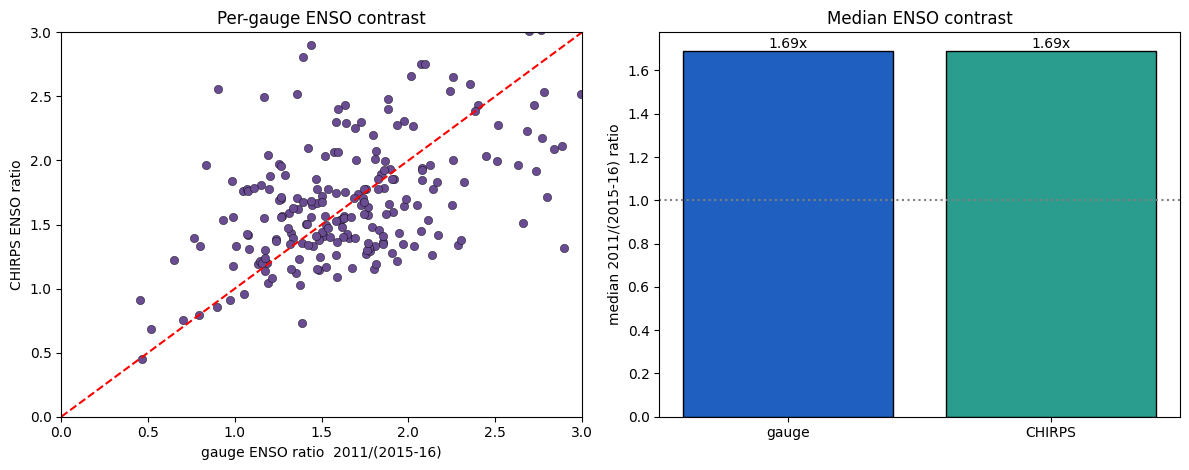

median ENSO ratio  gauge 1.69x  |  CHIRPS 1.69x  (CHIRPS retains 100 % of the observed contrast)
gauges where both agree on sign (2011 wetter): 95 %


In [8]:
pv = pair.copy(); pv['yr'] = pv.date.dt.year
grp = pv.groupby(['code', 'yr'])[['precip_mm', 'chirps_mm']].sum().reset_index()
w  = grp[grp.yr == 2011].set_index('code')
d  = grp[grp.yr.isin([2015, 2016])].groupby('code')[['precip_mm', 'chirps_mm']].mean()
j  = w.join(d, lsuffix='_11', rsuffix='_56', how='inner')
j  = j[(j.precip_mm_56 > 0) & (j.chirps_mm_56 > 0)]
rg = (j.precip_mm_11 / j.precip_mm_56).median()
rc = (j.chirps_mm_11 / j.chirps_mm_56).median()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
ax[0].scatter(j.precip_mm_11/j.precip_mm_56, j.chirps_mm_11/j.chirps_mm_56,
              s=36, c='#6a4c93', edgecolor='k', lw=.3)
lim = 3.0; ax[0].plot([0, lim], [0, lim], 'r--'); ax[0].set_xlim(0, lim); ax[0].set_ylim(0, lim)
ax[0].set_xlabel('gauge ENSO ratio  2011/(2015-16)'); ax[0].set_ylabel('CHIRPS ENSO ratio')
ax[0].set_title('Per-gauge ENSO contrast')
ax[1].bar(['gauge', 'CHIRPS'], [rg, rc], color=['#1f5fbf', '#2a9d8f'], edgecolor='k')
ax[1].axhline(1, color='grey', ls=':'); ax[1].set_ylabel('median 2011/(2015-16) ratio')
for i, v in enumerate([rg, rc]):
    ax[1].text(i, v, f'{v:.2f}x', ha='center', va='bottom')
ax[1].set_title('Median ENSO contrast')
plt.tight_layout(); plt.show()

print(f'median ENSO ratio  gauge {rg:.2f}x  |  CHIRPS {rc:.2f}x  '
      f'(CHIRPS retains {100*(rc-1)/(rg-1):.0f} % of the observed contrast)')
print(f'gauges where both agree on sign (2011 wetter): '
      f'{((j.precip_mm_11>j.precip_mm_56)==(j.chirps_mm_11>j.chirps_mm_56)).mean()*100:.0f} %')

## Verdict

### Part 1 — which gauge network (tests 1–4): **conventional**

| | Conventional | Automatic |
|---|---|---|
| Stations / station-days | **294 / 686,752** | 94 / 70,367 |
| Median distance to nearest gauge | **16 km** | 46 km |
| Basin >30 km from any gauge | **17 %** | 63 % |
| Annual total vs the other network | reference | **under-catches ~31 %** |
| Quality control | IDEAM approval flag | raw |

The automatic network is disqualified on all four counts. Its under-catch of ~31 % is the decisive
one: an under-catching gauge does not just add noise, it biases calibration, and a rainfall bias
absorbed into the soil parameters would give the right discharge for the wrong physical reasons —
which then corrupts the sediment module, where rainfall must be right in its own terms.

### Part 2 — gauges or CHIRPS (tests 5–7): **neither alone — CHIRPS as backbone, corrected to gauges**

The framing "which one is better" turns out to be the wrong question, and the numbers show why: the
two sources fail in *complementary* ways, so the answer is not a choice but a combination.

**What the gauges have that CHIRPS cannot supply — local truth.** They are physical measurements at
a point, quality-flagged by IDEAM, and they capture real storm intensities. But 17 % of the basin
sits more than 30 km from any gauge, and the gaps are concentrated in the high, remote headwaters —
precisely the steep terrain that generates most of the sediment. Interpolating 294 points across
8672 minibacias would invent spatial structure that the data does not contain.

**What CHIRPS has that the gauges cannot supply — complete coverage.** Every minibacia gets a value,
from a product already blended with gauge data and purpose-built for tropical, ENSO-scale rainfall
monitoring. Its weakness is the one that matters most here: it is not an independent measurement in
the ungauged headwaters, where it falls back on cold-cloud-duration IR (weak for warm orographic
rain) and a monthly climatology.

**Why raw CHIRPS is rejected as the erosion forcing.** Test 6 is the blocking result. The daily
CHIRPS field is disaggregated from 5-day pentads, so day-to-day storm placement is smeared, and
area-averaging over 5 km damps convective peaks. Since MUSLE erosion is driven by extremes, using
raw CHIRPS would systematically under-force the sediment module even where its annual totals look
correct. Good totals are not sufficient — the distribution has to be right.

**Why the gauges are not redundant with CHIRPS.** CHIRPS only ingests gauges shared internationally,
and most IDEAM stations are not in that pool. Correcting CHIRPS against our own 294-station dataset
therefore adds genuinely new local information rather than re-using what is already inside the
product.

### Decision for notebook 11

Use **CHIRPS as the spatial backbone, quantile-mapped onto the 294 conventional gauges**, with
**ERA5-Land supplying the energy variables** (`t2m`, `d2m`, `ssrd`, `u10/v10`, `sp`) for full
Penman–Monteith PET. Quantile mapping is chosen over simple monthly scaling specifically because it
corrects the *distribution* — restoring the extreme tail that Test 6 shows is damped — rather than
only the mean.

**Stated honestly:** the high, ungauged headwaters remain uncertain under any method. That is a
data-availability limit of this basin, not a modelling choice, and it should be carried into the
uncertainty discussion of the final report rather than hidden.